In [1]:
### Import Libraries
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

# Workout - Parking Tickets PDX (Pre Cleaned)

![Cars Parked in the City of Portland](../images/stock/pexels-brett-sayles-3995715.jpg)
image credit: [Pexels](https://www.pexels.com)

Ask and you shall receive...

Early this term, I requested a years worth of parking data from [Portland's Public Records](https://www.portland.gov/public-records). With in a week, I was sent 250,000 rows of parking ticket data!

# 0. Importing and Inspecting the Data

The files used for this workout is located at the following path:

* Parking Violations CSV - `../data/parking_tickets_pdx/C455259_Data.csv`
* Parking Violation Codes XLSX - `../data/parking_tickets_pdx/Offences.xlsx`

Import the data and do the usual: 

- [ ] Inspect the dataset, looking for issues and quirks
- [ ] Preview a few rows of data

In [2]:
### Your Solution
tickets_file = "../data/parking_tickets_pdx/C455259_Data.csv"
offenses_file = "../data/parking_tickets_pdx/Offences.xlsx"

tickets_df = pd.read_csv(tickets_file)
offenses_df = pd.read_excel(offenses_file)

/Users/mmw23/Library/jupyterlab-desktop/jlab_server/lib/python3.12/site-packages/openpyxl/worksheet/header_footer.py:48: UserWarning: Cannot parse header or footer so it will be ignored
  warn("""Cannot parse header or footer so it will be ignored""")


## 0.1 Parking Tickets Overview

Inspect the Parking Tickets DataFrame

In [3]:
tickets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Ticket no.        249944 non-null  object 
 1   District          250000 non-null  object 
 2   Street            250000 non-null  object 
 3   House no          26894 non-null   object 
 4   Local detail      6040 non-null    object 
 5   between           217123 non-null  object 
 6   and               217123 non-null  object 
 7   GPS               249472 non-null  object 
 8   From (Date-Time)  250000 non-null  object 
 9   To (Date-Time)    250000 non-null  object 
 10  State             233628 non-null  object 
 11  Vehicle type      0 non-null       float64
 12  Vehicle make      249999 non-null  object 
 13  Offense 1         250000 non-null  int64  
 14  Amount            250000 non-null  int64  
dtypes: float64(1), int64(2), object(12)
memory usage: 28.6+ MB


## 0.2 Offenses Overview

Inspect the Offenses DataFrame.

In [4]:
offenses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   Offence code  95 non-null     int64 
 1   Amount        95 non-null     int64 
 2   Long text     95 non-null     object
dtypes: int64(2), object(1)
memory usage: 2.4+ KB


# 1. Cleaning

Investigate the dataset and perform all of the necessary cleaning and modifications.

Make sure that you have at least handled the following:

- [ ] Null Values
- [ ] Data Type Conversions
- [ ] Column Naming Consistency

__Consideration:__

* How will you handle the `GPS` column?
* How might you make  use of the Violation Codes in the `Offenses.xlsx` file and the `Offense 1` column in the larger dataset?

## 1.1 Standardizing Columns

Standardize the columns of both DataFrames. 

Consider the following:
* removing leading and trailing whitespace
* converting to all lower case
* replacing blankspaces with underscores

In [5]:
# Standardize Columns
def standardize_columns(dataframe):
    dataframe.columns = (
        dataframe.columns
        .str.strip()
        .str.lower()
        .str.replace(" ", "_")
        .str.replace("offence", "offense")
        .str.replace(r"\.$", "", regex=True)
    )

    return dataframe
    
tickets_df = standardize_columns(tickets_df)
offenses_df = standardize_columns(offenses_df)

In [6]:
# Tickets Dataframe
tickets_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ticket_no         249944 non-null  object 
 1   district          250000 non-null  object 
 2   street            250000 non-null  object 
 3   house_no          26894 non-null   object 
 4   local_detail      6040 non-null    object 
 5   between           217123 non-null  object 
 6   and               217123 non-null  object 
 7   gps               249472 non-null  object 
 8   from_(date-time)  250000 non-null  object 
 9   to_(date-time)    250000 non-null  object 
 10  state             233628 non-null  object 
 11  vehicle_type      0 non-null       float64
 12  vehicle_make      249999 non-null  object 
 13  offense_1         250000 non-null  int64  
 14  amount            250000 non-null  int64  
dtypes: float64(1), int64(2), object(12)
memory usage: 28.6+ MB


In [7]:
# Offenses Dataframe
offenses_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 95 entries, 0 to 94
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   offense_code  95 non-null     int64 
 1   amount        95 non-null     int64 
 2   long_text     95 non-null     object
dtypes: int64(2), object(1)
memory usage: 2.4+ KB


## 1.2 Merging Dataframes

Merge both dataframes.

Consider:
* joining on the `offense_1` column of the parking tickets dataframe and   `offense_code` of the offenses dataframe
* dropping columns you may no longer need after the join is complete

Note:
* the `offense_code` column may have a different name if it wasn't changed during the column cleaning step.

In [8]:
# Merge the two dataframe
parking_df_clean = pd.merge(
    tickets_df,
    offenses_df[["offense_code","long_text"]],
    left_on="offense_1",
    right_on="offense_code",
    how="left"
).drop(columns=["offense_1", "offense_code"])

parking_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 15 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ticket_no         249944 non-null  object 
 1   district          250000 non-null  object 
 2   street            250000 non-null  object 
 3   house_no          26894 non-null   object 
 4   local_detail      6040 non-null    object 
 5   between           217123 non-null  object 
 6   and               217123 non-null  object 
 7   gps               249472 non-null  object 
 8   from_(date-time)  250000 non-null  object 
 9   to_(date-time)    250000 non-null  object 
 10  state             233628 non-null  object 
 11  vehicle_type      0 non-null       float64
 12  vehicle_make      249999 non-null  object 
 13  amount            250000 non-null  int64  
 14  long_text         249944 non-null  object 
dtypes: float64(1), int64(1), object(13)
memory usage: 28.6+ MB


## 1.3 Dropping Columns

Are there columns that should be completely dropped? Take some time to either remove some columns or skip this step and deal with the columns later in some other way.

In [9]:
### Your Solution

# Drop Columns
columns_to_drop = ["local_detail", "vehicle_type"]

parking_df_clean = parking_df_clean.drop(
    columns= columns_to_drop
)

parking_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   ticket_no         249944 non-null  object
 1   district          250000 non-null  object
 2   street            250000 non-null  object
 3   house_no          26894 non-null   object
 4   between           217123 non-null  object
 5   and               217123 non-null  object
 6   gps               249472 non-null  object
 7   from_(date-time)  250000 non-null  object
 8   to_(date-time)    250000 non-null  object
 9   state             233628 non-null  object
 10  vehicle_make      249999 non-null  object
 11  amount            250000 non-null  int64 
 12  long_text         249944 non-null  object
dtypes: int64(1), object(12)
memory usage: 24.8+ MB


## 1.4 Fill NaN (Categorical)

Replace the null values of the categorical columns.

***Consider creating a null map*** for a clean solution.

In [10]:
# Columns to Fill
columns_to_fill = [
    "ticket_no",
    "house_no",
    "between",
    "and",
    "gps",
    "long_text",
    "state",
    "vehicle_make"
]

# Dictionary for Filling NaNs
fill_map = {column: "UNKNOWN" for column in columns_to_fill}

parking_df_clean = parking_df_clean.fillna(fill_map)

parking_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 13 columns):
 #   Column            Non-Null Count   Dtype 
---  ------            --------------   ----- 
 0   ticket_no         250000 non-null  object
 1   district          250000 non-null  object
 2   street            250000 non-null  object
 3   house_no          250000 non-null  object
 4   between           250000 non-null  object
 5   and               250000 non-null  object
 6   gps               250000 non-null  object
 7   from_(date-time)  250000 non-null  object
 8   to_(date-time)    250000 non-null  object
 9   state             250000 non-null  object
 10  vehicle_make      250000 non-null  object
 11  amount            250000 non-null  int64 
 12  long_text         250000 non-null  object
dtypes: int64(1), object(12)
memory usage: 24.8+ MB


## 1.5 Latitude and Longitude

Clean up the latitude and longitude columns.

1. Create separate columns for each coordinate
2. Split the `gps` column into the new columns created in the previous step
3. Convert  the new coordinate columns into numeric datatypes
4. Drop the `gps` column now that you have a separate column for longitude and latitude.

In [11]:
# Create Latitude and Longitude Columns
parking_df_clean[["latitude", "longitude"]] = parking_df_clean["gps"].str.split(
    ";",
    expand=True
)

# Apply Numeric Conversion to Both Columns
parking_df_clean[["latitude","longitude"]] = parking_df_clean[["latitude","longitude"]].apply(
    pd.to_numeric, 
    errors="coerce"
)

# Drop the GPS Column
parking_df_clean = parking_df_clean.drop(
    columns="gps"
)

parking_df_clean.sample(10)

,ticket_no,district,street,house_no,between,and,from_(date-time),to_(date-time),state,vehicle_make,amount,long_text,latitude,longitude
23705,HA37116213,SW,3RD AVE,UNKNOWN,JEFFERSON ST,COLUMBIA ST,5/12/2023 12:19,5/12/2023 12:20,OR,UNKNOWN,85,NO PARKING ANYTIME,45.513971,-122.677638
120531,HA37238450,SW,TAYLOR ST,UNKNOWN,1ST AVE,2ND AVE,2/5/2024 10:45,2/5/2024 10:46,OR,TOYOTA,65,NO METER RECEIPT,45.516740,-122.675270
18215,HA37004950,SE,BELMONT ST,UNKNOWN,33RD AVE,32ND AVE,4/29/2023 17:41,4/29/2023 17:42,WA,VOLKSWAGEN,85,NO PARKING ANYTIME,45.516358,-122.630929
1630,HA37052620,NW,KEARNEY ST,UNKNOWN,19TH AVE,18TH AVE,1/14/2023 9:21,1/14/2023 9:22,CA,TOYOTA,85,UPPER NW AREA PERMIT REQUIRED,45.529211,-122.690095
98931,HA37209757,SW,BROADWAY,UNKNOWN,SALMON ST,MAIN ST,11/17/2023 18:35,11/17/2023 18:36,OR,FORD,65,NO METER RECEIPT,45.516799,-122.680412
235551,HA37346463,NW,16TH AVE,UNKNOWN,SAVIER ST,THURMAN ST,10/24/2024 15:33,10/24/2024 15:34,OR,TESLA,85,NO PARKING ANYTIME,45.509220,-122.673568
32306,HA37130908,NW,11TH AVE,UNKNOWN,FLANDERS ST,GLISAN ST,6/4/2023 12:41,6/4/2023 12:42,OR,FORD,145,FAILURE TO DISPLAY CURRENT REGISTRATION (91 OR...,45.527531,-122.685544
247357,HA37373307,NW,VISTA AVE,864,UNKNOWN,UNKNOWN,11/23/2024 11:37,11/23/2024 11:37,OR,NISSAN,145,FAILURE TO DISPLAY CURRENT REGISTRATION (91 OR...,45.537253,-122.688640
436,HA37071332,N,MISSISSIPPI AVE,UNKNOWN,RUSSELL ST,KNOTT ST,1/6/2023 8:03,1/6/2023 8:04,OR,HONDA,95,LOADING ZONE,45.537500,-122.666680
27148,HA37130311,SW,MAIN ST,UNKNOWN,20TH AVE,19TH AVE,5/20/2023 18:38,5/20/2023 20:40,OR,HYUNDAI,85,AREA PERMIT REQUIRED,45.519733,-122.693656


## 1.6 Missing Latitude and Longitude

Fill the any missing latitude and longitude values.

Consider the following:
* Would replacing the missing coordinates with the median of an entire column be the best course of action?
* How might we get a more accurate (but not perfect) median value to replace missing values with?

In [12]:
# Set Up Columns
columns_to_fix = ["latitude", "longitude"]

# Apply Median Value based on Distict Groups
for column in columns_to_fix:
    parking_df_clean[column] = parking_df_clean[column].fillna(
        parking_df_clean.groupby("district")[column].transform("median")
    )

parking_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   ticket_no         250000 non-null  object 
 1   district          250000 non-null  object 
 2   street            250000 non-null  object 
 3   house_no          250000 non-null  object 
 4   between           250000 non-null  object 
 5   and               250000 non-null  object 
 6   from_(date-time)  250000 non-null  object 
 7   to_(date-time)    250000 non-null  object 
 8   state             250000 non-null  object 
 9   vehicle_make      250000 non-null  object 
 10  amount            250000 non-null  int64  
 11  long_text         250000 non-null  object 
 12  latitude          250000 non-null  float64
 13  longitude         250000 non-null  float64
dtypes: float64(2), int64(1), object(11)
memory usage: 26.7+ MB


## 1.7 DateTime Conversions

Convert the time-related columns to date time objects

In [13]:
# Datetime Conversion
columns_to_fix = ["from_(date-time)", "to_(date-time)"]

parking_df_clean[columns_to_fix] = parking_df_clean[columns_to_fix].apply(
    pd.to_datetime,
    errors="coerce",
    format="%m/%d/%Y %H:%M"
)

parking_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 14 columns):
 #   Column            Non-Null Count   Dtype         
---  ------            --------------   -----         
 0   ticket_no         250000 non-null  object        
 1   district          250000 non-null  object        
 2   street            250000 non-null  object        
 3   house_no          250000 non-null  object        
 4   between           250000 non-null  object        
 5   and               250000 non-null  object        
 6   from_(date-time)  250000 non-null  datetime64[ns]
 7   to_(date-time)    250000 non-null  datetime64[ns]
 8   state             250000 non-null  object        
 9   vehicle_make      250000 non-null  object        
 10  amount            250000 non-null  int64         
 11  long_text         250000 non-null  object        
 12  latitude          250000 non-null  float64       
 13  longitude         250000 non-null  float64       
dtypes: d

## 1.8 Cleaning the Streets

The street columns, specially the `between` and `and` columns are a bit strange. How might you transform the data to make it make sense in terms of the column names?

In [14]:
# Create Cross Streets Column
parking_df_clean["intersection"] = "BETWEEN " + parking_df_clean["between"] + " AND " + parking_df_clean["and"]

# Drop Between and And
columns_to_drop = ["between", "and"]

parking_df_clean = parking_df_clean.drop(
    columns=columns_to_drop
)

parking_df_clean["intersection"].sample(10)

51805                BETWEEN UNKNOWN AND UNKNOWN
211361               BETWEEN UNKNOWN AND UNKNOWN
72837              BETWEEN 11TH AVE AND 12TH AVE
146514           BETWEEN SALMON ST AND TAYLOR ST
226091               BETWEEN 4TH AVE AND 5TH AVE
173257    BETWEEN BURNSIDE ST AND HARVEY MILK ST
191966         BETWEEN ST CLAIR AVE AND KING AVE
55884               BETWEEN 6TH AVE AND BROADWAY
105270               BETWEEN 5TH AVE AND 6TH AVE
77228          BETWEEN JACKSON ST AND COLLEGE ST
Name: intersection, dtype: object

## 1.9 Rename Columns (optional)

Rename any other columns for spelling or clarity.

In [15]:
# Rename Columns
rename_map = {
    "from_(date-time)": "start_time",
    "to_(date-time)": "end_time",
    "long_text": "violation",
    "house_no": "house_number",
    "ticket_no": "ticket_id",
    "state": "license_plate_state",
    "amount": "fine_amount"
}

parking_df_clean = parking_df_clean.rename(columns=rename_map)

parking_df_clean.columns

Index(['ticket_id', 'district', 'street', 'house_number', 'start_time',
       'end_time', 'license_plate_state', 'vehicle_make', 'fine_amount',
       'violation', 'latitude', 'longitude', 'intersection'],
      dtype='object')

## 1.10 Column Order (optional)

Rearrange the column order as you would like.

In [16]:
# Preferred Order
column_order = [
    "ticket_id",
    "start_time",
    "end_time",
    "district",
    "street",
    "intersection",
    "latitude",
    "longitude",
    "vehicle_make",
    "license_plate_state",
    "violation",
    "fine_amount",
]

parking_df_clean = parking_df_clean[column_order]

parking_df_clean.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 12 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   ticket_id            250000 non-null  object        
 1   start_time           250000 non-null  datetime64[ns]
 2   end_time             250000 non-null  datetime64[ns]
 3   district             250000 non-null  object        
 4   street               250000 non-null  object        
 5   intersection         250000 non-null  object        
 6   latitude             250000 non-null  float64       
 7   longitude            250000 non-null  float64       
 8   vehicle_make         250000 non-null  object        
 9   license_plate_state  250000 non-null  object        
 10  violation            250000 non-null  object        
 11  fine_amount          250000 non-null  int64         
dtypes: datetime64[ns](2), float64(2), int64(1), object(7)
memory usage: 22.9

# 2. Data Discoveries

Now that the data is clean(er), dive and and see what you can discover. Consider creating a visualization for each analysis

## 2.1 Vehicle Counts

### 2.1.1 __Common Cars__

Which `vehicle make` appears the most? Why might this be?

Text(0.5, 0, '\n\nTicket Count\n')

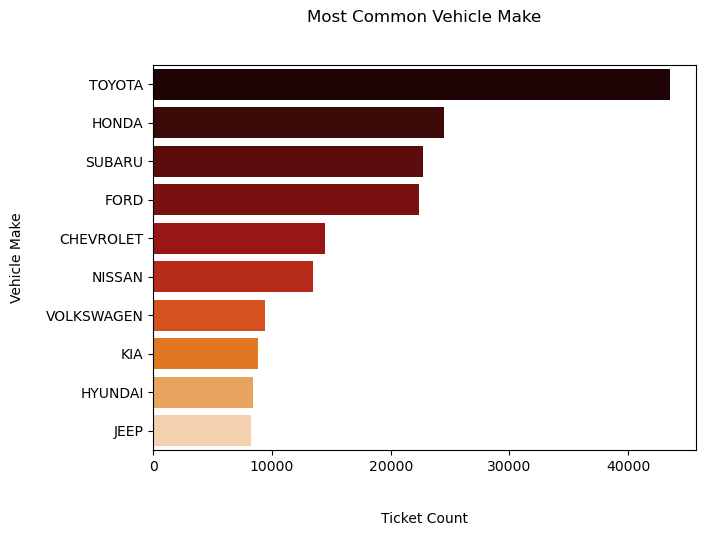

In [17]:
## Your Solution
vehicle_makes = parking_df_clean["vehicle_make"].value_counts().head(10).reset_index("vehicle_make")

plt.figure(figsize=(7,5))
           
sns.barplot(
    data=vehicle_makes,
    x="count",
    y="vehicle_make",
    hue="vehicle_make",
    palette="gist_heat"
)

plt.title("Most Common Vehicle Make\n\n")
plt.ylabel("Vehicle Make\n")
plt.xlabel("\n\nTicket Count\n")

### 2.1.2 __Exotic Cars__

How many Lamborghinis and Ferraris appear in this dataset?

Are there any other exotic cars in the data?


Text(0.5, 0, 'Count')

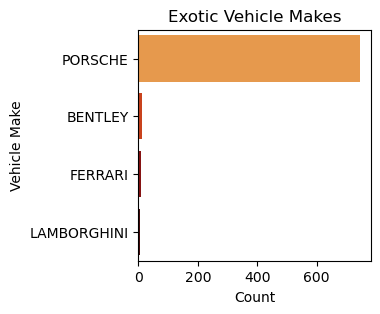

In [18]:
exotic_cars = ["FERRARI", "LAMBORGHINI", "BUGATTI", "PORSCHE", "MCLAREN", "ASTON MARTIN", "BENTLEY", "ROLLS-ROYCE"]

exotic_car_count = parking_df_clean[parking_df_clean["vehicle_make"].isin(exotic_cars)]["vehicle_make"].value_counts().reset_index()

plt.figure(figsize=(3,3))

sns.barplot(
    data=exotic_car_count,
    y="vehicle_make",
    x="count",
    hue="vehicle_make",
    palette="gist_heat_r"
)

plt.title("Exotic Vehicle Makes")
plt.ylabel("Vehicle Make")
plt.xlabel("Count")

# 3. Fees and Violations

## 3.1 What are the most common violations?

In [19]:
### Your Solution

violation_total_fees = parking_df_clean.groupby("violation")["fine_amount"].sum().sort_values(
    ascending=False
).head(10).reset_index("violation")

violation_total_fees

,violation,fine_amount
0,FAILURE TO DISPLAY CURRENT REGISTRATION (91 OR...,5873370
1,NO METER RECEIPT,5242120
2,NO PARKING ANYTIME,1547340
3,LOADING ZONE,1360400
4,NO FRONT OR REAR PLATE,784550
5,UPPER NW AREA PERMIT REQUIRED,782340
6,OVERTIME METER,683276
7,FIRE HYDRANT,634725
8,FAILURE TO DISPLAY CURRENT REGISTRATION (0 TO ...,558810
9,AREA PERMIT REQUIRED,550460


## 3.2 What is the total for all fees owed for based on the available data?

In [20]:
f"Total Parking Violation Fine Amount: ${parking_df_clean["fine_amount"].sum().item():,}"

'Total Parking Violation Fine Amount: $21,831,124'

## 3.3 Which violations have the largest total fees for the entire dataset?

Text(0, 0.5, 'Violation')

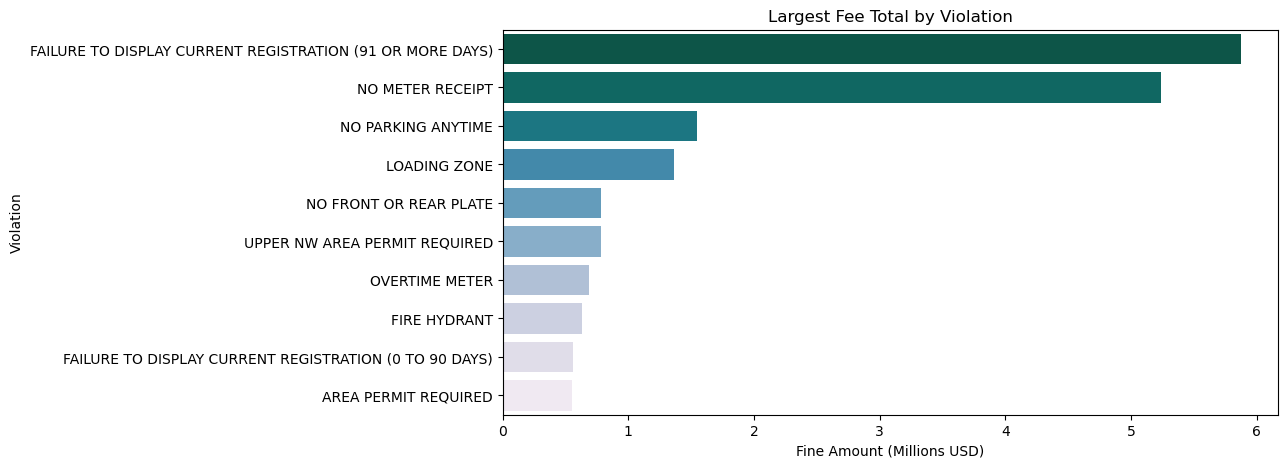

In [21]:
violation_total_fees["fine_amount"] = (violation_total_fees["fine_amount"] / 1_000_000)

plt.figure(figsize=(10,5))

sns.barplot(
    data=violation_total_fees,
    y="violation",
    x="fine_amount",
    hue="violation",
    palette="PuBuGn_r",
    
)

plt.title("Largest Fee Total by Violation")
plt.xlabel("Fine Amount (Millions USD)")
plt.ylabel("Violation")

# 4. Location Data

## 4.1 Which Districts Are Ticketed the Most?

How does each district rank in terms of Parking Ticket Count?

Text(0, 0.5, 'District')

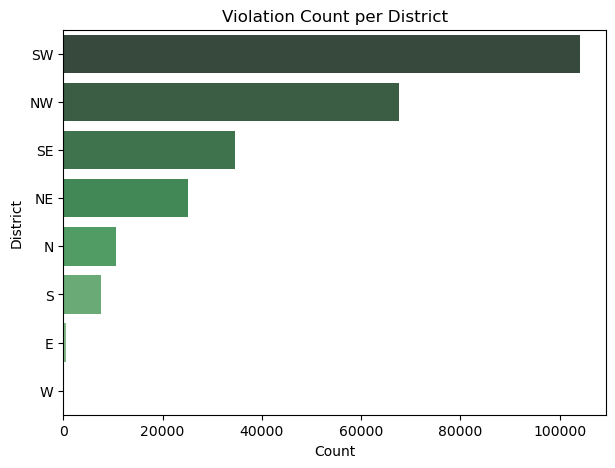

In [22]:
### Your Solution
district_violation_count = parking_df_clean.groupby("district")["violation"].count().reset_index("district").sort_values(by="violation", ascending=False)

plt.figure(figsize=(7,5))

sns.barplot(
    data=district_violation_count,
    y="district",
    x="violation",
    hue="district",
    palette="Greens_r_d"
)

plt.title("Violation Count per District")
plt.xlabel("Count")
plt.ylabel("District")

## 4.2 Ticket Hotspots

Visualize the parking ticket hotspots.
* Which areas are the hottest?
* Which areas are the coldest?
* Why might this be?

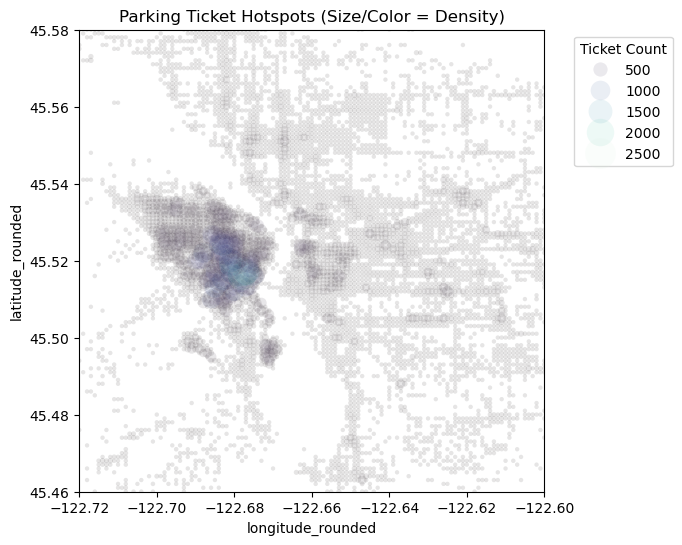

In [23]:
parking_df_clean["latitude_rounded"] = parking_df_clean["latitude"].round(3)
parking_df_clean["longitude_rounded"] = parking_df_clean["longitude"].round(3)

location_counts = (
    parking_df_clean
        .groupby(["latitude_rounded", "longitude_rounded"])
        .size().reset_index(name="ticket_count")
)

plt.figure(
    figsize=(6,6)
)

sns.scatterplot(
    data=location_counts,
    x="longitude_rounded",
    y="latitude_rounded",
    size="ticket_count",
    hue="ticket_count",
    palette="mako",
    sizes=(10,500),
    alpha=0.1,
)

plt.xlim(-122.72, -122.60)
plt.ylim(45.46, 45.58)

plt.title("Parking Ticket Hotspots (Size/Color = Density)")
plt.legend(title="Ticket Count", bbox_to_anchor=(1.05, 1), loc='upper left')

### Your Observation(s)

* Southwest Portland is pretty hot
* There are "warm" pockets scattered throughout the area

## 4.3 Most Ticketed Street

Which streets have the most tickets?

Text(0.5, 0, '\nTotal Number of Violations\n')

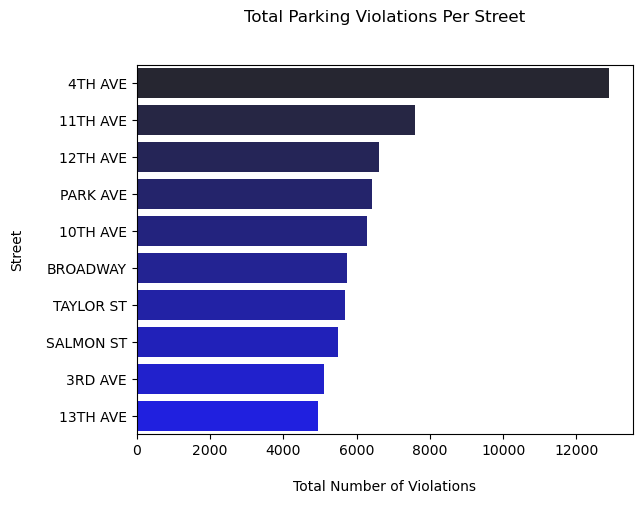

In [24]:
street_violation_count = (
    parking_df_clean
    .groupby("street")["violation"].count()
    .reset_index("street")
    .sort_values(by="violation", ascending=False).head(10)
)

sns.barplot(
    data=street_violation_count,
    y="street",
    x="violation",
    palette="dark:blue",
    hue="street"
)

plt.title("Total Parking Violations Per Street\n\n")
plt.ylabel("Street\n")
plt.xlabel("\nTotal Number of Violations\n")

### Your Observation(s)

* 4th Avenue has over 12,000 parking violations.

## Most Common Violations on the Most Ticketed Street

Which violations are the most common the this street?

Text(0.5, 0, 'Count')

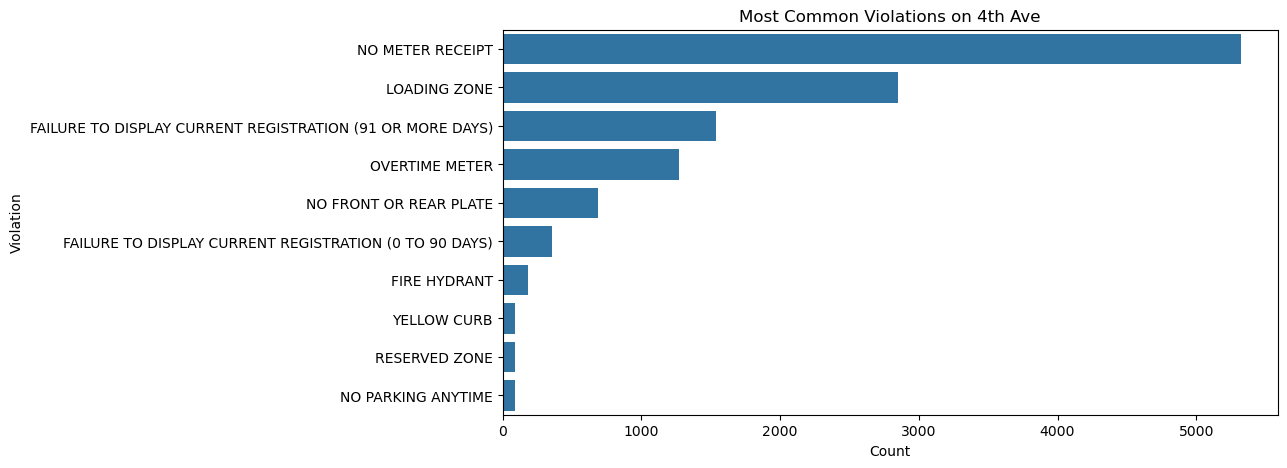

In [25]:
### Your Solution
fourth_ave = parking_df_clean[parking_df_clean["street"] == "4TH AVE"]["violation"].value_counts().reset_index("violation").head(10)

plt.figure(figsize=(10,5))
sns.barplot(
    data=fourth_ave,
    y="violation",
    x="count"
)

plt.title("Most Common Violations on 4th Ave")
plt.ylabel("Violation")
plt.xlabel("Count")

### Your Observation(s)

* Meter Receipt and Loading Zone were the most common violations
* Are people just not paying to park? Or do they not know to include the reciept in their window?
* Are people just parking in Loading Zones? Or are the rules unclear?
    * Based on the data, it seems folks know not to park near a hydrant, yellow curb, reserved zone, or no parking zone...what's up with the Loading Zones? 

# 5. Time

## 5.1 Are there any patterns to the hours in tickets are issued?

Consider creating new columns for this task:
* hour (`dt.hour`)

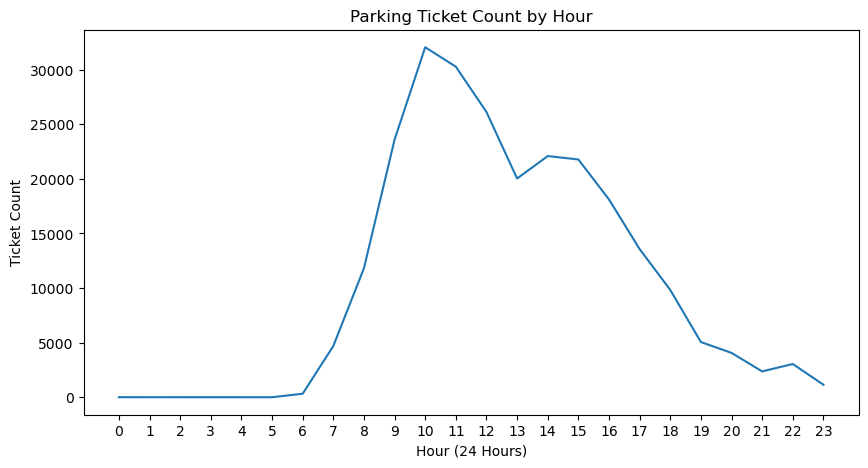

In [26]:
### Your Solution
parking_df_clean["hour"] = parking_df_clean["start_time"].dt.hour



hourly_counts = parking_df_clean.groupby("hour").size().reset_index(name="ticket_count")

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly_counts,
    x="hour",
    y="ticket_count"
)

plt.title("Parking Ticket Count by Hour")
plt.ylabel("Ticket Count")
plt.xlabel("Hour (24 Hours)")
plt.xticks(range(0,24))

plt.show()

### Your Observation(s)

* Parking enforcement rapidly increases in the morning.
* Peak enforcement is at 10am followed by a decline until 1pm. (Could this be a lunch break for parking enforcement?
* There is a an increase from 1pm to 2pm.

## 5.2 Are there any patterns to the days in tickets are issued?

Consider creating new columns for this task:
* day (`dt.day_name()`)

Text(0.5, 0, 'Day of the Week (Aggregated)')

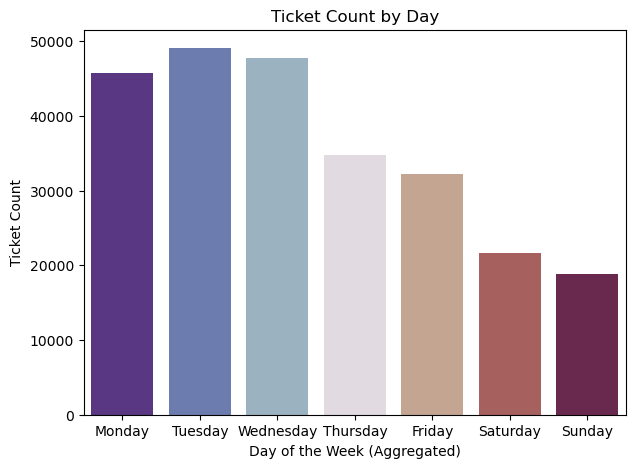

In [27]:
### Your Solution

day_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]

parking_df_clean["day"] = parking_df_clean["start_time"].dt.day_name()


parking_df_clean["day"] = pd.Categorical(
    parking_df_clean["day"], 
    categories=day_order, 
    ordered=True
)

day_count = parking_df_clean.groupby("day", observed=False).size().reset_index(name="ticket_count")

plt.figure(figsize=(7,5))

sns.barplot(
    data=day_count,
    x="day",
    y="ticket_count",
    hue="day",
    palette="twilight_shifted"
)

plt.title("Ticket Count by Day")
plt.ylabel("Ticket Count")
plt.xlabel("Day of the Week (Aggregated)")


# 6. More to Explore (Optional)

There are still more insights to discover. Add cells below to make new discoveries or to answer your unique questions based on this dataset.

# 7. Reflection

Take some time to think, reflect, and discuss on this activity.

* What did you learn today that was new for you?
* Will the data and insights gained from today change how you go about your day-to-day in any way?
    * If so, how?
    * If not, why not?
* How might today's discoveries be useful to people?
* Did you label the axes of your visualizations?